# Tarea Redes Bipartitas

### Integrantes:

- Jorge Miyoshi Mikami Alonso
- Luis Manuel Reyes Colín


In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Datos

Afluencia diaria de Metrobús CDMX (junio y julio de 2018). La red bipartita tiene de un lado las líneas del Metrobús y del otro los días, y el peso de cada arista es la afluencia de esa línea en ese día.


In [2]:
df = pd.read_excel("para_clase_redes_bipartitas.xlsx", usecols="A:E")
print(df.shape)
df.head()

(428, 5)


,fecha,anio,mes,linea,afluencia
0,NaT,NaN,NaN,NaN,NaN
1,2018-06-01,2018.0,Junio,LÃ­nea 3,185939.0
2,2018-06-01,2018.0,Junio,LÃ­nea 4,68183.0
3,2018-06-01,2018.0,Junio,LÃ­nea 2,199248.0
4,2018-06-01,2018.0,Junio,LÃ­nea 6,233478.0


## Ejercicio 1

Quitar el valor Nan o NaT de los datos y en consecuencia del dibujo de la red (o sea ningún nodo debe tener esta etiqueta).


In [ ]:
print("Valores nulos por columna:\n", df.isna().sum(), "\n")

df = df.dropna().copy()


# Los nombres de las líneas vienen mal 
def arregla_nombre(texto):
    try:
        return texto.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return texto


df["linea"] = df["linea"].apply(arregla_nombre)

print("Filas después de limpiar:", len(df))
print(list(df["linea"].unique()))

Valores nulos por columna:
 fecha        1
anio         1
mes          1
linea        1
afluencia    1
dtype: int64 

Filas después de limpiar: 427
['Línea 3', 'Línea 4', 'Línea 2', 'Línea 6', 'Línea 7', 'Línea 1', 'Línea 5']


In [ ]:
lineas = sorted(df["linea"].unique())
dias = sorted(df["fecha"].unique())

aristas = [(f.linea, f.fecha, f.afluencia) for f in df.itertuples()]

B = nx.Graph()
B.add_nodes_from(lineas, bipartite=0)
B.add_nodes_from(dias, bipartite=1)
B.add_weighted_edges_from(aristas)

print("Nodos:", B.number_of_nodes(), "(", len(lineas), "líneas y", len(dias), "días )")
print("Aristas:", B.number_of_edges())
print("Es bipatita:", nx.is_bipartite(B))
print("Algún nodo NaN o Na:", any(pd.isna(n) for n in B.nodes))

Nodos: 68 ( 7 líneas y 61 días )
Aristas: 427
Es bipartita: True
Algún nodo NaN o NaT: False


## Ejercicio 2

Obtener una lista con la Centralidad de Grado pesado de cada línea de Metrobús, para los meses de junio y julio de 2018 mediante algún comando de NetworkX.


In [5]:
dias_junio = [d for d in dias if d.month == 6]
dias_julio = [d for d in dias if d.month == 7]

# Subredes de cada mes: todas las líneas con los días de ese mes
B_junio = B.subgraph(lineas + dias_junio)
B_julio = B.subgraph(lineas + dias_julio)

lista_junio = list(B_junio.degree(lineas, weight="weight"))
lista_julio = list(B_julio.degree(lineas, weight="weight"))

print("Junio 2018")
for linea, grado in lista_junio:
    print(f"{linea}: {grado:,.0f}")

print("\nJulio 2018")
for linea, grado in lista_julio:
    print(f"{linea}: {grado:,.0f}")

Junio 2018
Línea 1: 12,760,729
Línea 2: 4,832,742
Línea 3: 4,529,292
Línea 4: 1,755,216
Línea 5: 2,440,864
Línea 6: 5,604,819
Línea 7: 2,841,521

Julio 2018
Línea 1: 12,620,239
Línea 2: 4,586,583
Línea 3: 4,618,581
Línea 4: 1,779,771
Línea 5: 2,384,586
Línea 6: 5,301,058
Línea 7: 2,772,155


## Ejercicio 3

Dibujar la red con Pathpy o NetworkX, poniendo diferente tamaño a los nodos que representan las líneas del Metrobús de acuerdo a su grado pesado, todos los demás nodos deberán tener el mismo tamaño. Adicionalmente, colorear todos los nodos de algún tono de verde y todas las aristas de algún tono de morado.


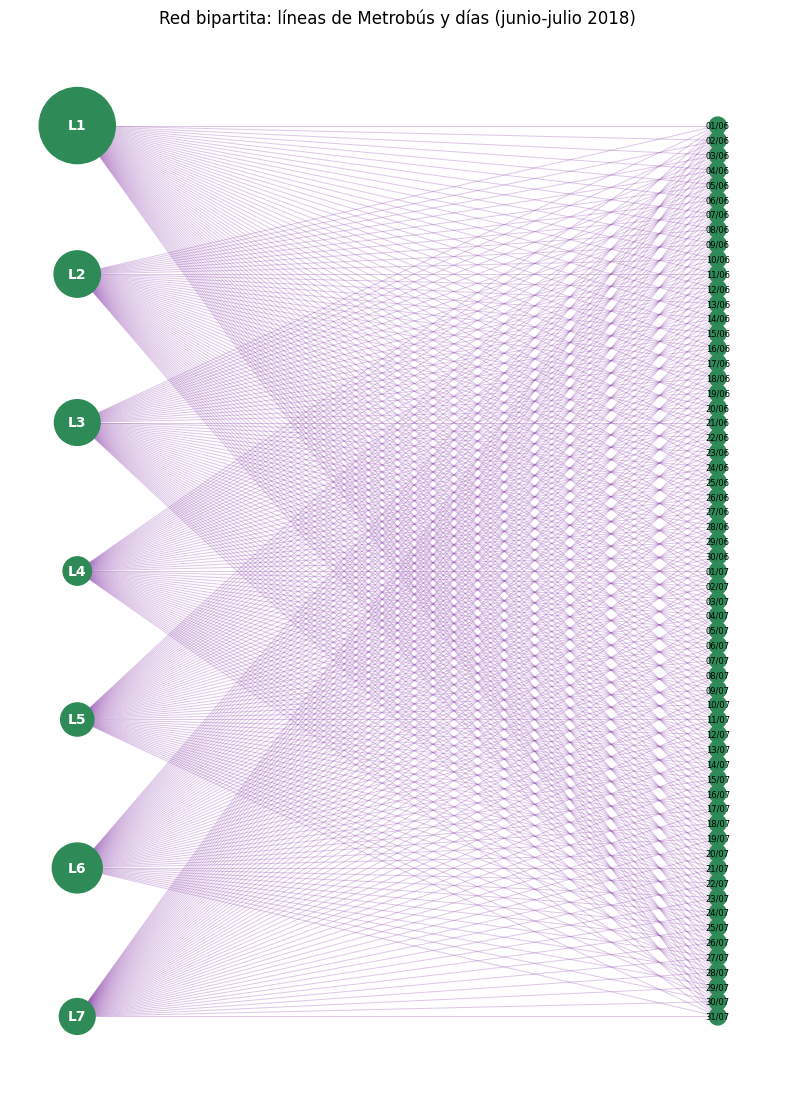

In [6]:
# Grado pesado de cada línea tomando los dos meses juntos
grado_total = dict(B.degree(lineas, weight="weight"))
max_grado = max(grado_total.values())

# Líneas: tamaño proporcional al grado pesado, días: todos del mismo tamaño
tam_nodos = [3000 * grado_total[n] / max_grado if n in grado_total else 150 for n in B.nodes]

etiquetas_lineas = {linea: "L" + linea.split()[-1] for linea in lineas}
etiquetas_dias = {dia: dia.strftime("%d/%m") for dia in dias}

# Líneas a la izquierda y días a la derecha, ambos en orden (de arriba hacia abajo)
pos = {}
for i, linea in enumerate(lineas):
    pos[linea] = (0, -i / (len(lineas) - 1))
for i, dia in enumerate(dias):
    pos[dia] = (1, -i / (len(dias) - 1))

plt.figure(figsize=(10, 14))
nx.draw_networkx_edges(B, pos, edge_color="#8e44ad", alpha=0.3, width=0.7)
nx.draw_networkx_nodes(B, pos, node_color="#2e8b57", node_size=tam_nodos)
nx.draw_networkx_labels(B, pos, labels=etiquetas_lineas, font_size=10, font_color="white", font_weight="bold")
nx.draw_networkx_labels(B, pos, labels=etiquetas_dias, font_size=6)
plt.title("Red bipartita: líneas de Metrobús y días (junio-julio 2018)")
plt.axis("off")
plt.show()

## Ejercicio 4

¿Cuáles son las 3 líneas que tuvieron mayor afluencia en junio de 2018? Ordenar la respuesta en forma descendente.


In [7]:
top_junio = sorted(lista_junio, key=lambda x: x[1], reverse=True)[:3]

for linea, afluencia in top_junio:
    print(f"{linea}: {afluencia:,.0f}")

Línea 1: 12,760,729
Línea 6: 5,604,819
Línea 2: 4,832,742


## Ejercicio 5

¿Cuáles son las 3 líneas que tuvieron mayor afluencia en julio de 2018? Ordenar la respuesta en forma descendente.


In [8]:
top_julio = sorted(lista_julio, key=lambda x: x[1], reverse=True)[:3]

for linea, afluencia in top_julio:
    print(f"{linea}: {afluencia:,.0f}")

Línea 1: 12,620,239
Línea 6: 5,301,058
Línea 3: 4,618,581


## Ejercicio 6

¿Cuáles son las 3 líneas que tuvieron mayor afluencia en ambos meses? Ordenar la respuesta en forma descendente.


In [9]:
# Afluencia de junio + julio por línea
top_ambos = sorted(grado_total.items(), key=lambda x: x[1], reverse=True)[:3]

for linea, afluencia in top_ambos:
    print(f"{linea}: {afluencia:,.0f}")

# Si se pidieran solo las que están en el top 3 de los dos meses a la vez
en_ambos = {l for l, _ in top_junio} & {l for l, _ in top_julio}
print("\nEn el top 3 de junio y de julio a la vez:", sorted(en_ambos))

Línea 1: 25,380,968
Línea 6: 10,905,877
Línea 2: 9,419,325

En el top 3 de junio y de julio a la vez: ['Línea 1', 'Línea 6']
